# Spacing Statistics

## 1. Importing / Installing Packages

In [1]:
import os # Importing os module for operating system dependent functionality

import pandas as pd # Importing pandas package

# Set the maximum number of columns to display to None
pd.set_option('display.max_columns', None)

import numpy as np # Importing numpy package

from typing import Dict, Tuple, List, Union, Optional, ClassVar, Any # Importing specific types from typing module

from src.utils import DatabricksOdbcConnector # Importing DatabricksOdbcConnector class from database_manager module

from tqdm import tqdm # Importing tqdm for progress bar functionality

from joblib import Parallel, delayed # Importing Parallel and delayed for parallel processing

from matplotlib import pyplot as plt # Importing pyplot from matplotlib for plotting

from pyproj import Geod # Importing Geod class from pyproj for geodetic calculations

# Setting matplotlib to inline mode for Jupyter notebooks
%matplotlib inline

%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

from src.well_data import WellDataLoader, GeoSurveyProcessor # Importing custom classes for well data management

from __future__ import annotations # Enabling future annotations for type hinting

# from src.utils import reorder_columns # Importing utility function to reorder DataFrame columns

## 2. Defining Functions

### 2.1. Defining Functions that is used in calculation for i-k pair dataframe and Spacing Stats

In [2]:
class WellSpacingCalculator:
    """
    Class for calculating well spacing metrics and directional relationships using
    3D lateral midpoint alignment and curvature-aware distances.
    Midpoints are projected in 2D space to remove lateral-length bias when calculating spacing.
    """

    # Class-level constant (shared, immutable-by-convention)
    _DIR4_LABELS: ClassVar[np.ndarray] = np.array(["N", "E", "S", "W"], dtype=object)

    def __init__(self, trajectories: Union[Dict[str, pd.DataFrame], pd.DataFrame]):
        if isinstance(trajectories, pd.DataFrame):
            if "uwi" not in trajectories.columns:
                raise ValueError("Trajectory DataFrame must contain 'uwi' column.")
            self._trajectory_df = trajectories.reset_index(drop=True)
            self.trajectories = {
                cid: group for cid, group in self._trajectory_df.groupby("uwi")
            }
        elif isinstance(trajectories, dict):
            self.trajectories = trajectories
            self._trajectory_df = pd.concat(
                trajectories.values(), keys=trajectories.keys()
            ).reset_index(drop=True)
        else:
            raise ValueError("Invalid type for trajectories. Must be DataFrame or Dict.")

    def _calculate_spacing_statistics(
        self,
        frac: float = 0.5,
        batch_size: int = 1_000_000,
        max_distance_miles: Optional[float] = 20.0,
        save_batches_dir: Optional[str] = None,
        use_interpolation: bool = True,
        *,
        # new knobs
        step_ft: int = 100,
        n_samples: Optional[int] = None,
        max_crossline_ft: Optional[float] = 900.0,
        crossline_percentile: float = 5.0,
        ds_crossline_step_ft: int = 300,
        emit_rejected: bool = False,
        use_pca_axis: bool = True,
    ) -> Optional[pd.DataFrame]:
        """
        Compute spacing distances between well pairs using the overlap → clip → sample method.
        Produces horizontal (mean |Δx| with Y-alignment), vertical (from midpoints), 3D,
        and geodetic 8-way modal direction across the overlapped segment.
        """
        # Build the pair cache once (vectorized coarse arrays + local frames)
        self._build_pair_cache(
            use_pca_axis=use_pca_axis,
            ds_crossline_step_ft=ds_crossline_step_ft,
        )

        # 1) Midpoints + drill dirs (vertical uses these)
        midpoint_df = self._compute_normalized_midpoints(frac=frac, use_interpolation=use_interpolation)
        drill_dirs = self._compute_drill_directions()
        midpoint_df["drill_direction"] = drill_dirs

        # 2) Arrays
        ids = midpoint_df.index.to_numpy()
        coords = midpoint_df[["x", "y", "tvd"]].to_numpy()
        lat_lon = midpoint_df[["latitude", "longitude"]].to_numpy()
        directions = midpoint_df["drill_direction"].to_numpy()

        # 3) Candidate pairs
        if max_distance_miles is not None:
            lat = lat_lon[:, 0]
            lon = lat_lon[:, 1]
            i_idx, k_idx = self._filter_close_pairs(lat, lon, max_distance_miles)
        else:
            i_idx, k_idx = self._get_pairwise_indices(ids)

        pairs = list(zip(i_idx, k_idx))
        batch_generator = list(self._batch_filtered_indices(pairs, batch_size=batch_size))
        n_batches = len(batch_generator)

        if save_batches_dir:
            os.makedirs(save_batches_dir, exist_ok=True)

        def process_and_save(batch_number: int, i_idx: np.ndarray, k_idx: np.ndarray):
            batch_df = self._process_batch(
                i_idx, k_idx, ids, coords, directions,
                step_ft=step_ft, n_samples=n_samples,
                max_crossline_ft=max_crossline_ft,
                crossline_percentile=crossline_percentile,
                ds_crossline_step_ft=ds_crossline_step_ft,
                emit_rejected=emit_rejected, use_pca_axis=use_pca_axis,
            )
            if save_batches_dir:
                filepath = os.path.join(save_batches_dir, f"spacing_batch_{batch_number:04d}.parquet")
                batch_df.to_parquet(filepath, index=False)
            return batch_df

        tqdm_kwargs = {
            "desc": "🚀 Calculating Spacing (Parallel)",
            "dynamic_ncols": True,
            "smoothing": 0.3,
            "bar_format": "{desc}: |{bar:40}| {percentage:3.0f}% {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
            "ascii": "░▒█",
            "leave": True,
        }

        results = Parallel(n_jobs=-1)(
            delayed(process_and_save)(batch_num, i_idx, k_idx)
            for batch_num, (i_idx, k_idx) in tqdm(enumerate(batch_generator), total=n_batches, **tqdm_kwargs)
        )

        if save_batches_dir:
            print(f"✅ All batches saved to {save_batches_dir}")
            return None
        return pd.concat(results, ignore_index=True) if results else pd.DataFrame()
    
    def _load_saved_batches(self, batch_folder: str) -> pd.DataFrame:
        """
        Load all saved spacing batch Parquet files from a folder and combine into a single DataFrame.

        Parameters
        ----------
        batch_folder : str
            Path to the folder where batch Parquet files are stored.

        Returns
        -------
        pd.DataFrame
            Combined spacing DataFrame.
        """
        if not os.path.isdir(batch_folder):
            raise FileNotFoundError(f"Batch folder '{batch_folder}' not found.")

        batch_files = sorted([
            os.path.join(batch_folder, f)
            for f in os.listdir(batch_folder)
            if f.endswith(".parquet")
        ])

        if not batch_files:
            raise ValueError(f"No Parquet files found in folder '{batch_folder}'.")

        print(f"🔍 Found {len(batch_files)} batch files. Loading and combining...")

        dfs = []
        for file in batch_files:
            dfs.append(pd.read_parquet(file))

        combined_df = pd.concat(dfs, ignore_index=True)
        print(f"✅ Loaded {len(combined_df):,} rows from all batches.")
        return combined_df

    def _filter_close_pairs(self, lat: np.ndarray, lon: np.ndarray, max_distance_miles: float = 20.0) -> Tuple[np.ndarray, np.ndarray]:

        lat1, lat2 = np.meshgrid(lat, lat, indexing="ij")
        lon1, lon2 = np.meshgrid(lon, lon, indexing="ij")

        delta_lat = np.abs(lat1 - lat2)
        delta_lon = np.abs(lon1 - lon2)

        miles_per_lat_degree = 69.0
        miles_per_lon_degree = 69.0 * np.cos(np.radians(lat))
        miles_per_lon_degree_matrix = np.add.outer(miles_per_lon_degree, miles_per_lon_degree) / 2.0

        rough_dist_miles = np.sqrt(
            (delta_lat * miles_per_lat_degree)**2 + (delta_lon * miles_per_lon_degree_matrix)**2
        )

        mask = (rough_dist_miles <= max_distance_miles) & (delta_lat + delta_lon > 0)
        i_idx, k_idx = np.where(mask)

        return i_idx, k_idx

    def _get_pairwise_indices(self, uwis: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate all valid pairwise (i, k) UWI combinations from an array of well IDs,
        excluding self-comparisons (i != k).

        Parameters
        ----------
        uwis : np.ndarray
            Array of unique well identifiers.

        Returns
        -------
        Tuple[np.ndarray, np.ndarray]
            Two 1D arrays of i and k UWIs representing all valid (i, k) pairs.
        """
        # Generate meshgrid of all possible UWI pairs
        n = len(uwis)
        i_idx, k_idx = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
            
        # Exclude self-comparisons (where i_uwi == k_uwi)
        valid_mask = i_idx != k_idx

        return i_idx[valid_mask], k_idx[valid_mask]

    def _batch_filtered_indices(self, pairs: List[Tuple[int, int]], batch_size: int = 1_000_000):
        """
        Vectorized batching of prefiltered well pairs.

        Parameters
        ----------
        pairs : List[Tuple[int, int]]
            List of (i_idx, k_idx) pairs.
        batch_size : int
            Number of pairs per batch.

        Yields
        ------
        Tuple[np.ndarray, np.ndarray]
            i_idx and k_idx arrays for each batch.
        """
        pairs_array = np.array(pairs)  # Convert list of tuples directly to 2D array (N, 2)
        n_pairs = pairs_array.shape[0]

        # Vectorized slicing
        split_indices = np.arange(0, n_pairs, batch_size)

        for start_idx in split_indices:
            end_idx = min(start_idx + batch_size, n_pairs)
            batch = pairs_array[start_idx:end_idx]
            yield batch[:, 0], batch[:, 1]

    def _compute_normalized_midpoints(self, frac: float = 0.5, use_interpolation: bool = True) -> pd.DataFrame:
        """
        Computes midpoints for each well either by interpolating along the well trajectory
        using MD-based fractional position or by averaging heel and toe coordinates.

        Parameters:
        -----------
        frac : float
            Fractional location along the lateral to compute the midpoint (0.0 to 1.0).
        use_interpolation : bool
            If True, uses curvature-aware interpolation along MD.
            If False, uses geometric midpoint between heel and toe.

        Returns:
        --------
        pd.DataFrame indexed by 'uwi', containing:
            ['x', 'y', 'tvd', 'latitude', 'longitude']
        """
        df = self._trajectory_df.copy()
        df = df.sort_values(["uwi", "md"]).reset_index(drop=True)

        if not use_interpolation:
            # Simple geometric midpoint (fast)
            heel_toe_df = (
                df.groupby("uwi")
                .agg(
                    heel_x=("x", "first"),
                    heel_y=("y", "first"),
                    heel_tvd=("tvd", "first"),
                    heel_lat=("latitude", "first"),
                    heel_lon=("longitude", "first"),
                    toe_x=("x", "last"),
                    toe_y=("y", "last"),
                    toe_tvd=("tvd", "last"),
                    toe_lat=("latitude", "last"),
                    toe_lon=("longitude", "last"),
                )
            )

            midpoint_df = pd.DataFrame({
                "x": (heel_toe_df["heel_x"] + heel_toe_df["toe_x"]) / 2,
                "y": (heel_toe_df["heel_y"] + heel_toe_df["toe_y"]) / 2,
                "tvd": (heel_toe_df["heel_tvd"] + heel_toe_df["toe_tvd"]) / 2,
                "latitude": (heel_toe_df["heel_lat"] + heel_toe_df["toe_lat"]) / 2,
                "longitude": (heel_toe_df["heel_lon"] + heel_toe_df["toe_lon"]) / 2,
            })
            midpoint_df.index.name = "uwi"
            return midpoint_df

        # Interpolated midpoint (MD-based)
        min_md = df.groupby("uwi")["md"].transform("min")
        max_md = df.groupby("uwi")["md"].transform("max")
        df["normalized_md"] = (df["md"] - min_md) / (max_md - min_md)

        df["row_index"] = df.groupby("uwi").cumcount()
        df["prev_idx"] = df.groupby("uwi")["normalized_md"].transform(lambda x: x.searchsorted(frac, side="right") - 1)
        df["next_idx"] = df["prev_idx"] + 1
        df["next_idx"] = np.minimum(df["next_idx"], df["row_index"].groupby(df["uwi"]).transform("max"))

        df_prev = df.groupby("uwi").apply(lambda g: g.loc[g["row_index"] == g["prev_idx"].iloc[0]]).reset_index(drop=True)
        df_next = df.groupby("uwi").apply(lambda g: g.loc[g["row_index"] == g["next_idx"].iloc[0]]).reset_index(drop=True)

        merged = pd.merge(df_prev, df_next, on="uwi", suffixes=("_prev", "_next"))

        delta = merged["normalized_md_next"] - merged["normalized_md_prev"]
        delta = delta.replace(0, np.nan)
        ratio = (frac - merged["normalized_md_prev"]) / delta

        midpoint_df = pd.DataFrame({
            "x": merged["x_prev"] + ratio * (merged["x_next"] - merged["x_prev"]),
            "y": merged["y_prev"] + ratio * (merged["y_next"] - merged["y_prev"]),
            "tvd": merged["tvd_prev"] + ratio * (merged["tvd_next"] - merged["tvd_prev"]),
            "latitude": merged["latitude_prev"] + ratio * (merged["latitude_next"] - merged["latitude_prev"]),
            "longitude": merged["longitude_prev"] + ratio * (merged["longitude_next"] - merged["longitude_prev"]),
        })
        midpoint_df["uwi"] = merged["uwi"]
        return midpoint_df.set_index("uwi")
    
    def _compute_drill_directions(self) -> pd.Series:
        median_azimuth = self._trajectory_df.groupby("uwi")["azimuth"].median()
        is_ew = ((median_azimuth >= 45) & (median_azimuth <= 135)) | ((median_azimuth >= 225) & (median_azimuth <= 315))
        return pd.Series(np.where(is_ew, "EW", "NS"), index=median_azimuth.index, name="drill_direction")
    
    def _build_pair_cache(
        self,
        use_pca_axis: bool,
        ds_crossline_step_ft: int,
        ds_min_points: int = 16,
        ds_max_points: int = 64,
    ):
        """
        Precompute per-well:
        - origin, ex, ey (local frame metadata)
        - coarse resample XY (same length across wells) for vectorized cross-line precheck
        """
        # Compute each well's lateral length to pick a *global* coarse point count
        lengths = {}
        for uwi, df in self.trajectories.items():
            XY = df.sort_values("md")[["x","y"]].to_numpy()
            d = np.hypot(np.diff(XY[:,0]), np.diff(XY[:,1]))
            lengths[uwi] = float(d.sum())

        # Choose a *single* coarse count using median length / step, then clamp
        median_len = np.median(list(lengths.values())) if lengths else 3000.0
        m_guess = int(np.ceil(max(median_len, 1.0) / max(ds_crossline_step_ft, 1))) + 1
        M_ds = int(np.clip(m_guess, ds_min_points, ds_max_points))

        cache = {
            "origin": {},
            "ex": {},
            "ey": {},
            "XY_coarse": {},
            "M_ds": M_ds,
            "use_pca_axis": use_pca_axis,
        }

        for uwi, df in self.trajectories.items():
            df = df.sort_values("md")
            XY = df[["x","y"]].to_numpy()

            # local frame metadata
            pts = XY
            heel, toe = pts[0], pts[-1]
            origin = heel.copy()
            if use_pca_axis:
                C = pts - pts.mean(0)
                _, _, Vt = np.linalg.svd(C, full_matrices=False)
                ex = Vt[0]
                if np.dot(ex, toe - heel) < 0:
                    ex = -ex
            else:
                v = toe - heel
                ex = v / (np.linalg.norm(v) + 1e-12)
            ey = np.array([-ex[1], ex[0]])

            cache["origin"][uwi] = origin
            cache["ex"][uwi] = ex
            cache["ey"][uwi] = ey

            # coarse resample to common length M_ds by arclength
            d = np.hypot(np.diff(XY[:,0]), np.diff(XY[:,1]))
            s = np.concatenate([[0.0], np.cumsum(d)])
            L = s[-1] if s.size else 0.0
            if L <= 0.0:
                XYc = np.repeat(XY[:1], M_ds, axis=0)
            else:
                t = np.linspace(0.0, 1.0, M_ds)
                sx = np.interp(t*L, s, XY[:,0])
                sy = np.interp(t*L, s, XY[:,1])
                XYc = np.column_stack([sx, sy])

            cache["XY_coarse"][uwi] = XYc

        self._paircache = cache

    def _build_local_frame_from_i(self, df_i: pd.DataFrame, use_pca_axis: bool = True
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Build well_i's local frame from its UTM x,y points.
        origin: heel (first by MD); ex: along-lateral (PCA or heel→toe); ey: 90° CCW from ex.
        """
        pts = df_i.sort_values("md")[["x","y"]].to_numpy()
        heel, toe = pts[0], pts[-1]
        origin = heel.copy()

        if use_pca_axis:
            C = pts - pts.mean(0)
            _, _, Vt = np.linalg.svd(C, full_matrices=False)
            ex = Vt[0]
            if np.dot(ex, toe - heel) < 0:
                ex = -ex
        else:
            v = toe - heel
            ex = v / (np.linalg.norm(v) + 1e-12)

        ey = np.array([-ex[1], ex[0]])
        return origin, ex, ey
    
    def _project_xy_to_frame(self, df: pd.DataFrame, origin: np.ndarray, ex: np.ndarray, ey: np.ndarray
    ) -> np.ndarray:
        """Return Nx2 array of (x_local, y_local) from UTM x,y."""
        XY = df[["x","y"]].to_numpy()
        R = XY - origin
        return np.column_stack([R @ ex, R @ ey])
    
    def _clip_polyline_by_x_band(self, X: np.ndarray, band: Tuple[float, float]) -> np.ndarray:
        """
        Clip polyline X[:,0]=x, X[:,1]=y to x ∈ [x_lo, x_hi] and INSERT boundary
        intersection points by linear interpolation. Guarantees ≥2 points if the
        band intersects the polyline.
        """
        x_lo, x_hi = band
        x = X[:, 0]
        pts = []

        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]

            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo or seg_min > x_hi:
                continue  # segment outside band

            # keep start if inside
            if x_lo <= x0 <= x_hi:
                pts.append(P0)

            # intersections with boundaries (strict crossing)
            for xb in (x_lo, x_hi):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts.append(P0 + t * (P1 - P0))

            # keep end if last seg and inside
            if j == len(X) - 2 and (x_lo <= x1 <= x_hi):
                pts.append(P1)

        if not pts:
            return np.empty((0, 2))

        P = np.vstack(pts)
        # drop exact duplicates while preserving order
        keep = np.ones(len(P), dtype=bool)
        if len(P) > 1:
            dup = np.all(np.isclose(np.diff(P, axis=0), 0.0, atol=1e-9), axis=1)
            keep[1:] = ~dup
        return P[keep]
    
    def _clip_polyline_with_latlon_by_x_band(
        self,
        X: np.ndarray,         # (N,2) local-frame (x,y)
        lat: np.ndarray,       # (N,)
        lon: np.ndarray,       # (N,)
        band: Tuple[float, float]
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Returns (X_clip, lat_clip, lon_clip), each with >=2 points if band intersects.
        Boundary points are linearly interpolated (for both XY and lat/lon).
        """
        x_lo, x_hi = band
        x = X[:, 0]
        pts_xy, pts_lat, pts_lon = [], [], []

        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            lat0, lat1 = lat[j], lat[j + 1]
            lon0, lon1 = lon[j], lon[j + 1]

            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo or seg_min > x_hi:
                continue  # segment entirely outside band

            # keep start if inside
            if x_lo <= x0 <= x_hi:
                pts_xy.append(P0); pts_lat.append(lat0); pts_lon.append(lon0)

            # intersections with x_lo and x_hi (strict crossings)
            for xb in (x_lo, x_hi):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts_xy.append(P0 + t * (P1 - P0))
                    pts_lat.append(lat0 + t * (lat1 - lat0))
                    pts_lon.append(lon0 + t * (lon1 - lon0))

            # keep end if last seg and inside
            if j == len(X) - 2 and (x_lo <= x1 <= x_hi):
                pts_xy.append(P1); pts_lat.append(lat1); pts_lon.append(lon1)

        if not pts_xy:
            return np.empty((0, 2)), np.empty((0,)), np.empty((0,))

        XYc = np.vstack(pts_xy)
        latc = np.asarray(pts_lat, dtype=float)
        lonc = np.asarray(pts_lon, dtype=float)

        # drop adjacent duplicates (numeric noise)
        if len(XYc) > 1:
            dup = np.all(np.isclose(np.diff(XYc, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(XYc), dtype=bool); keep[1:] = ~dup
            XYc, latc, lonc = XYc[keep], latc[keep], lonc[keep]
        return XYc, latc, lonc
    
    def _arclength(self, X: np.ndarray) -> np.ndarray:
        """Cumulative arclength for 2D polyline (x,y)."""
        d = np.hypot(np.diff(X[:,0]), np.diff(X[:,1]))
        return np.concatenate([[0.0], np.cumsum(d)])
    
    def _interp_by_arclength(self, X: np.ndarray, s_targets: np.ndarray) -> np.ndarray:
        """
        Interpolate 2D polyline X to arclength grid s_targets. Returns Mx2 array.
        """
        s = self._arclength(X)
        keep = np.concatenate([[True], np.diff(s) > 1e-9])  # drop zero-length steps
        s, X = s[keep], X[keep]
        xi = np.interp(s_targets, s, X[:,0])
        yi = np.interp(s_targets, s, X[:,1])
        return np.column_stack([xi, yi])
    
    def _interp_attr_by_arclength(
        self,
        X: np.ndarray,          # (N,2) polyline
        attr: np.ndarray,       # (N,) attribute values (lat or lon)
        s_targets: np.ndarray   # (M,) arclength positions
    ) -> np.ndarray:
        s = self._arclength(X)
        keep = np.concatenate([[True], np.diff(s) > 1e-9])
        s, Xattr = s[keep], attr[keep]
        return np.interp(s_targets, s, Xattr)

    def _interp_y_of_x(self, X: np.ndarray, x_targets: np.ndarray) -> np.ndarray:
        """
        Piecewise-linear interpolation of y(x) on a 2D polyline X[:,0]=x, X[:,1]=y.
        Assumes x is roughly monotonic *within the clipped overlap*.
        Handles duplicate x by collapsing them.
        """
        x = X[:, 0]; y = X[:, 1]
        order = np.argsort(x)
        x_sorted = x[order]; y_sorted = y[order]
        keep = np.concatenate([[True], np.diff(x_sorted) > 1e-9])  # drop duplicate x
        x_sorted = x_sorted[keep]; y_sorted = y_sorted[keep]

        if x_sorted.size == 1:
            # Degenerate segment: constant y
            return np.full_like(x_targets, y_sorted[0], dtype=float)

        x_lo, x_hi = x_sorted[0], x_sorted[-1]
        xq = np.clip(x_targets, x_lo, x_hi)
        return np.interp(xq, x_sorted, y_sorted)

    def _crossline_spacing_from_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,
        *,
        step_ft: int
    ) -> Tuple[float, int, float]:
        """
        Map-style crossline spacing:
        - Build a common x-grid across the TRUE overlap band (in i-frame).
        - Interpolate y_i(x) and y_k(x).
        - Return mean(|Δy(x)|), number of stations, and overlap length in x.

        Returns: (cross_mean, n_stations, overlap_len_x)
        """
        if Xi_seg.size == 0 or Xk_seg.size == 0:
            return float("nan"), 0, 0.0

        xi_min, xi_max = float(Xi_seg[:,0].min()), float(Xi_seg[:,0].max())
        xk_min, xk_max = float(Xk_seg[:,0].min()), float(Xk_seg[:,0].max())
        x_lo, x_hi = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi > x_lo):
            return float("nan"), 0, 0.0

        step = max(int(step_ft or 100), 1)
        n = max(int(np.floor((x_hi - x_lo)/step)) + 1, 2)  # works even if overlap < step
        xgrid = np.linspace(x_lo, x_hi, n)

        yi = self._interp_y_of_x(Xi_seg, xgrid)
        yk = self._interp_y_of_x(Xk_seg, xgrid)
        dy = np.abs(yk - yi)

        cross_mean = float(dy.mean())
        return cross_mean, int(n), float(x_hi - x_lo)
    
    def _crossline_spacing_median_from_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,
        *,
        step_ft: int
    ) -> Tuple[float, int, float]:
        """
        Map-style crossline spacing (median):
        - Build a common x-grid across the TRUE overlap band (in i-frame).
        - Interpolate y_i(x) and y_k(x).
        - Return median(|Δy(x)|), number of stations, and overlap length in x.

        Returns: (cross_median, n_stations, overlap_len_x)
        """
        if Xi_seg.size == 0 or Xk_seg.size == 0:
            return float("nan"), 0, 0.0

        xi_min, xi_max = float(Xi_seg[:,0].min()), float(Xi_seg[:,0].max())
        xk_min, xk_max = float(Xk_seg[:,0].min()), float(Xk_seg[:,0].max())
        x_lo, x_hi = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi > x_lo):
            return float("nan"), 0, 0.0

        step = max(int(step_ft or 100), 1)
        n = max(int(np.floor((x_hi - x_lo)/step)) + 1, 2)
        xgrid = np.linspace(x_lo, x_hi, n)

        yi = self._interp_y_of_x(Xi_seg, xgrid)
        yk = self._interp_y_of_x(Xk_seg, xgrid)
        dy = np.abs(yk - yi)

        cross_median = float(np.median(dy))
        return cross_median, int(n), float(x_hi - x_lo)
    
    def _bin4_from_geod_az(self, az_deg_from_north: np.ndarray) -> np.ndarray:
        """
        Bin geodetic azimuths (0°=N, 90°=E, 180°=S, 270°=W) into 4 compass labels.
        Edges at 45°,135°,225°,315°. Returns array of {"N","E","S","W"}.
        """
        a = az_deg_from_north % 360.0
        idx = ((a + 45.0) // 90.0).astype(int) % 4  # 0:N, 1:E, 2:S, 3:W
        return self._DIR4_LABELS[idx]
    
    def _modal_direction_geodetic_over_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,          # local XY clipped segments
        lat_i_seg: np.ndarray, lon_i_seg: np.ndarray,    # clipped lat/lon for i
        lat_k_seg: np.ndarray, lon_k_seg: np.ndarray,    # clipped lat/lon for k
        step_ft: Optional[int], n_samples: Optional[int]
    ) -> Tuple[str, float, str]:
        """
        Returns (modal_direction_8way, confidence, distribution_string)
        using geodetic bearings at the same sample grid as spacing.
        """
        # Sample count (match spacing logic)
        si = self._arclength(Xi_seg); Li = si[-1]
        sk = self._arclength(Xk_seg); Lk = sk[-1]
        Lmin = max(min(Li, Lk), 1e-6)

        if n_samples is None:
            step = max(int(step_ft or 100), 1)
            n = max(int(np.floor(Lmin / step)) + 1, 2)
        else:
            n = max(int(n_samples), 2)
        t = np.linspace(0.0, 1.0, n)

        # Interpolate lat/lon by arclength within each clipped segment
        s_i = t * Li
        s_k = t * Lk
        lat_i = self._interp_attr_by_arclength(Xi_seg, lat_i_seg, s_i)
        lon_i = self._interp_attr_by_arclength(Xi_seg, lon_i_seg, s_i)
        lat_k = self._interp_attr_by_arclength(Xk_seg, lat_k_seg, s_k)
        lon_k = self._interp_attr_by_arclength(Xk_seg, lon_k_seg, s_k)

        # Geodetic forward azimuth i→k at each sample
        geod = Geod(ellps="WGS84")
        az12, _, _ = geod.inv(lon_i, lat_i, lon_k, lat_k)  # degrees, vectorized

        # 8-way bins + aggregation
        labels = self._bin4_from_geod_az(az12)  # az12 is 0°=N CW from Geod.inv
        # mode + confidence
        uniq, counts = np.unique(labels, return_counts=True)
        best_idx = np.argmax(counts)
        mode = uniq[best_idx]
        conf = counts[best_idx] / float(n)

        # compact distribution string for QA
        parts = [f"{u}:{c/float(n):.2f}" for u, c in sorted(zip(uniq, counts), key=lambda z: -z[1])]
        dist_str = ",".join(parts)
        return mode, conf, dist_str
    
    def _process_batch(
        self,
        i_idx: np.ndarray,
        k_idx: np.ndarray,
        ids: np.ndarray,
        coords: np.ndarray,        # midpoint coords [["x","y","tvd"]]
        directions: np.ndarray,    # drill dirs per well (EW/NS)
        *,
        step_ft: int,
        n_samples: Optional[int],
        max_crossline_ft: Optional[float],
        crossline_percentile: float,
        ds_crossline_step_ft: int,
        emit_rejected: bool,
        use_pca_axis: bool
    ) -> pd.DataFrame:
        """
        Vectorizes cross-line precheck per 'i'; loops only over survivor pairs
        for exact clip+sample+geodetic modal direction.
        Rejected rows have all computed metrics filled with NaN.
        """
        rows: List[Dict] = []
        cache = getattr(self, "_paircache", None)
        if cache is None or cache.get("use_pca_axis", None) != use_pca_axis:
            # Build cache once (local frames + coarse resamples)
            self._build_pair_cache(use_pca_axis, ds_crossline_step_ft)

        # Group pairs by source index i
        for i in np.unique(i_idx):
            mask_i = (i_idx == i)
            k_list = k_idx[mask_i]
            if k_list.size == 0:
                continue

            uwi_i = ids[i]
            origin_i = self._paircache["origin"][uwi_i]
            ex_i = self._paircache["ex"][uwi_i]
            ey_i = self._paircache["ey"][uwi_i]

            # Coarse arrays (vectorized across all neighbors k of this i)
            Pi_coarse = self._paircache["XY_coarse"][uwi_i]                               # (M_ds, 2)
            Pk_coarse = np.stack([self._paircache["XY_coarse"][ids[k]] for k in k_list])  # (K, M_ds, 2)

            # Project coarse to i's local frame
            Ri = Pi_coarse - origin_i                                                    # (M_ds, 2)
            Rk = Pk_coarse - origin_i[None, None, :]                                     # (K, M_ds, 2)
            xi = Ri @ ex_i                                                               # (M_ds,)
            yi = Ri @ ey_i                                                               # (M_ds,)
            xk = np.einsum("kmd,d->km", Rk, ex_i)                                        # (K, M_ds)
            yk = np.einsum("kmd,d->km", Rk, ey_i)                                        # (K, M_ds)

            # x-overlap bands per k (vectorized)
            xi_min, xi_max = float(xi.min()), float(xi.max())
            xk_min = xk.min(axis=1)                                                      # (K,)
            xk_max = xk.max(axis=1)                                                      # (K,)
            x_lo = np.maximum(xi_min, xk_min)                                            # (K,)
            x_hi = np.minimum(xi_max, xk_max)                                            # (K,)
            has_overlap = x_hi > x_lo                                                    # (K,)

            # Emit 'no_overlap_x' rejections (NaNs for metrics) and continue if none remain
            if not has_overlap.any():
                if emit_rejected:
                    for k in k_list:
                        rows.append({
                            "well_i": uwi_i, "well_k": ids[k],
                            "horizontal_dist": np.nan, "vertical_dist": np.nan, "3D_dist": np.nan,
                            "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                            "direction_to_k_from_i": np.nan, "direction_confidence": np.nan,
                            "direction_distribution": "",
                            "overlap_len_ft": np.nan, "n_samples": np.nan, "dy_p5": np.nan,
                            "reject_reason": "no_overlap_x"
                        })
                continue

            # Masks for 'inside band' (vectorized across k)
            mask_kj = (xk >= x_lo[:, None]) & (xk <= x_hi[:, None])                      # (K, M_ds)
            mask_km = (xi[None, :] >= x_lo[:, None]) & (xi[None, :] <= x_hi[:, None])    # (K, M_ds)

            # Downsampled cross-line guardrail (robust "min" via percentile)
            # Build (K, M_ds, M_ds) of |yk(k,j) - yi(m)|; mask outside band; min over j; percentile over m
            YK = yk[:, :, None]                                                          # (K, M_ds, 1)
            YI = yi[None, None, :]                                                       # (1, 1, M_ds)
            D = np.abs(YK - YI)                                                          # (K, M_ds, M_ds)
            mask_grid = mask_kj[:, :, None] & mask_km[:, None, :]                        # (K, M_ds, M_ds)
            D[~mask_grid] = np.inf

            Dmin_km = np.min(D, axis=1)                                                  # (K, M_ds)
            with np.errstate(invalid="ignore"):
                Dmin_km = np.where(np.isfinite(Dmin_km), Dmin_km, np.nan)
                dy_p = np.nanpercentile(Dmin_km, crossline_percentile, axis=1)           # (K,)

            keep = has_overlap.copy()
            if max_crossline_ft is not None:
                keep &= np.isfinite(dy_p) & (dy_p <= max_crossline_ft)

            # Emit 'too_crossline' rejections (NaNs for metrics)
            if emit_rejected:
                rej = (~keep) & has_overlap
                for idx, k in enumerate(k_list):
                    if rej[idx]:
                        rows.append({
                            "well_i": uwi_i, "well_k": ids[k],
                            "horizontal_dist": np.nan, "vertical_dist": np.nan, "3D_dist": np.nan,
                            "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                            "direction_to_k_from_i": np.nan, "direction_confidence": np.nan,
                            "direction_distribution": np.nan,
                            "overlap_len_ft": np.nan, "n_samples": np.nan, "dy_p5": np.nan,
                            "reject_reason": "too_crossline"
                        })

            # Nothing survives → next i
            if not keep.any():
                continue

            # Project full-resolution i once (for exact spacing & direction)
            df_i = self.trajectories[uwi_i].sort_values("md")
            Xi_full = self._project_xy_to_frame(df_i, origin_i, ex_i, ey_i)
            lat_i_full = df_i["latitude"].to_numpy(dtype=float)
            lon_i_full = df_i["longitude"].to_numpy(dtype=float)

            # Process survivors (small loop)
            for idx, k in enumerate(k_list):
                if not keep[idx]:
                    continue

                uwi_k = ids[k]
                band = (float(x_lo[idx]), float(x_hi[idx]))

                # Full-resolution projection for k
                df_k = self.trajectories[uwi_k].sort_values("md")
                Xk_full = self._project_xy_to_frame(df_k, origin_i, ex_i, ey_i)
                lat_k_full = df_k["latitude"].to_numpy(dtype=float)
                lon_k_full = df_k["longitude"].to_numpy(dtype=float)

                # Exact clip of XY + lat/lon (supports <100' overlaps)
                Xi_seg = self._clip_polyline_by_x_band(Xi_full, band)
                Xk_seg = self._clip_polyline_by_x_band(Xk_full, band)
                if Xi_seg.shape[0] == 0 or Xk_seg.shape[0] == 0:
                    # Extremely rare numeric edge; treat as no-overlap
                    if emit_rejected:
                        rows.append({
                            "well_i": uwi_i, "well_k": uwi_k,
                            "horizontal_dist": np.nan, "horizontal_dist_median": np.nan,
                            "vertical_dist": np.nan, "3D_dist": np.nan,
                            "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                            "direction_to_k_from_i": np.nan, "direction_confidence": np.nan,
                            "direction_distribution": np.nan,
                            "overlap_len_ft": np.nan, "n_samples": np.nan, "dy_p5": np.nan,
                            "reject_reason": "no_overlap_x"
                        })
                    continue

                Xi_seg_ll, lat_i_seg, lon_i_seg = self._clip_polyline_with_latlon_by_x_band(
                    Xi_full, lat_i_full, lon_i_full, band
                )
                Xk_seg_ll, lat_k_seg, lon_k_seg = self._clip_polyline_with_latlon_by_x_band(
                    Xk_full, lat_k_full, lon_k_full, band
                )

                # Map-style crossline spacing over the overlap: mean |Δy(x)|
                horiz_mean, n_used, Lmin = self._crossline_spacing_from_overlap(
                    Xi_seg, Xk_seg, step_ft=step_ft
                )

                # Median crossline spacing over the same overlap
                horiz_median, _, _ = self._crossline_spacing_median_from_overlap(
                    Xi_seg, Xk_seg, step_ft=step_ft
                )

                # Geodetic modal direction over same samples
                dir_mode, dir_conf, dir_dist = self._modal_direction_geodetic_over_overlap(
                    Xi_seg, Xk_seg, lat_i_seg, lon_i_seg, lat_k_seg, lon_k_seg,
                    step_ft=step_ft, n_samples=n_samples
                )

                # Vertical from midpoints
                A = coords[i]; B = coords[k]
                vertical = float(abs(B[2] - A[2]))
                dist3d = float(np.hypot(horiz_mean, vertical))

                rows.append({
                    "well_i": uwi_i, "well_k": uwi_k,
                    "horizontal_dist": horiz_mean,               # mean |Δy(x)|
                    "horizontal_dist_median": horiz_median,      # median |Δy(x)|  <-- NEW 
                    "vertical_dist": vertical, "3D_dist": dist3d,
                    "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                    "direction_to_k_from_i": dir_mode,
                    "direction_confidence": dir_conf,
                    "direction_distribution": dir_dist,
                    "overlap_len_ft": Lmin, "n_samples": n_used,
                    "dy_p5": float(dy_p[idx]) if np.isfinite(dy_p[idx]) else np.nan,
                    "reject_reason": ""
                })

        return pd.DataFrame(rows)

### 2.2. Defining Functions that is used for debugging

In [15]:
def debug_pair_spacing(
    df: pd.DataFrame,
    uwi_i: Union[str, int],
    uwi_k: Union[str, int],
    *,
    step_ft: int = 100,
    use_pca_axis: bool = True,
    save_dir: Optional[Union[str, os.PathLike]] = None,
    figure_prefix: str = "spacing",
    show: bool = True
) -> Dict[str, Any]:
    """
    Debug the spacing between two wells using:
      (1) Align-Y spacing (mean |Δx|) on arclength samples in well-i local frame,
      (2) Map-style crossline spacing (mean/median/percentiles of |Δy(x)|) on a shared x-grid across the true overlap,
      (3) Direction i→k at the same crossline x-grid stations (4-way N/E/S/W; geodetic preferred if lat/lon available).

    Parameters
    ----------
    df : pd.DataFrame
        Full directional-survey table; must include ['uwi','md','x','y'] in feet (UTM or local).
        Optional for geodetic directions: ['latitude','longitude'] in degrees (WGS84).
    uwi_i, uwi_k : identifiers for the two wells to compare
    step_ft : sampling step (ft) for both align-Y and crossline metrics (default 100).
    use_pca_axis : if True, well-i local x-axis = PCA(1) (heel→toe oriented). Else heel→toe vector.
    save_dir : if provided, saves individual PNGs there.
    figure_prefix : filename prefix for saved figures.
    show : if True, shows a combined figure with 2 columns (all panels same size).

    Returns
    -------
    Dict[str, Any] with keys:
      'overlap_x_band' : (x_lo, x_hi) in the i-frame
      'alignY_mean_dx_ft', 'alignY_n_samples'
      'crossline_mean_ft', 'crossline_median_ft', 'crossline_p05_ft', 'crossline_p95_ft', 'crossline_n_stations'
      'direction_mode_4way', 'direction_confidence', 'direction_distribution' (dict of N/E/S/W -> fraction)
      'paths' : dict of saved image paths (if save_dir provided)
    """
    # --------- Input checks ---------
    for col in ("uwi", "md", "x", "y"):
        if col not in df.columns:
            raise ValueError(f"df must contain column '{col}'")
    has_ll = ("latitude" in df.columns) and ("longitude" in df.columns)
    geod = None
    if has_ll:
        try:
            from pyproj import Geod
            geod = Geod(ellps="WGS84")
        except Exception:
            geod = None
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # --------- Select wells & sort by MD ---------
    df_i = df[df["uwi"] == uwi_i].sort_values("md").copy()
    df_k = df[df["uwi"] == uwi_k].sort_values("md").copy()
    if df_i.empty or df_k.empty:
        raise ValueError("One or both UWIs not found in df.")

    # --------- Helpers ---------
    def build_local_frame_from_i(df_i_: pd.DataFrame, use_pca: bool) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        pts = df_i_[["x", "y"]].to_numpy()
        heel, toe = pts[0], pts[-1]
        origin_ = heel.copy()
        if use_pca:
            C = pts - pts.mean(0)
            _, _, Vt = np.linalg.svd(C, full_matrices=False)
            ex_ = Vt[0]
            if np.dot(ex_, toe - heel) < 0:  # orient heel→toe
                ex_ = -ex_
        else:
            v = toe - heel
            ex_ = v / (np.linalg.norm(v) + 1e-12)
        ey_ = np.array([-ex_[1], ex_[0]])
        return origin_, ex_, ey_

    def project_xy_to_frame(df_: pd.DataFrame, origin_: np.ndarray, ex_: np.ndarray, ey_: np.ndarray) -> np.ndarray:
        XY = df_[["x", "y"]].to_numpy()
        R = XY - origin_
        return np.column_stack([R @ ex_, R @ ey_])

    def arclength(X: np.ndarray) -> np.ndarray:
        d = np.hypot(np.diff(X[:, 0]), np.diff(X[:, 1]))
        return np.concatenate([[0.0], np.cumsum(d)])

    def interp_by_arclength(X: np.ndarray, s_targets: np.ndarray) -> np.ndarray:
        s = arclength(X)
        keep = np.concatenate([[True], np.diff(s) > 1e-9])
        s, Xc = s[keep], X[keep]
        xi = np.interp(s_targets, s, Xc[:, 0])
        yi = np.interp(s_targets, s, Xc[:, 1])
        return np.column_stack([xi, yi])

    def x_overlap_interval(Xi_: np.ndarray, Xk_: np.ndarray) -> Optional[Tuple[float, float]]:
        xi_min, xi_max = Xi_[:, 0].min(), Xi_[:, 0].max()
        xk_min, xk_max = Xk_[:, 0].min(), Xk_[:, 0].max()
        x_lo_, x_hi_ = max(xi_min, xk_min), min(xi_max, xk_max)
        return (x_lo_, x_hi_) if x_hi_ > x_lo_ else None

    def clip_polyline_by_x_band(X: np.ndarray, band: Tuple[float, float]) -> np.ndarray:
        x_lo_, x_hi_ = band
        x = X[:, 0]
        pts = []
        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo_ or seg_min > x_hi_:
                continue
            if x_lo_ <= x0 <= x_hi_:
                pts.append(P0)
            for xb in (x_lo_, x_hi_):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts.append(P0 + t * (P1 - P0))
            if j == len(X) - 2 and (x_lo_ <= x1 <= x_hi_):
                pts.append(P1)
        if not pts:
            return np.empty((0, 2))
        P = np.vstack(pts)
        if len(P) > 1:
            dup = np.all(np.isclose(np.diff(P, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(P), dtype=bool); keep[1:] = ~dup
            P = P[keep]
        return P

    def clip_polyline_with_latlon_by_x_band(
        X: np.ndarray, lat: np.ndarray, lon: np.ndarray, band: Tuple[float, float]
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        x_lo_, x_hi_ = band
        x = X[:, 0]
        pts_xy, pts_lat, pts_lon = [], [], []
        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            lat0, lat1 = lat[j], lat[j + 1]
            lon0, lon1 = lon[j], lon[j + 1]
            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo_ or seg_min > x_hi_:
                continue
            if x_lo_ <= x0 <= x_hi_:
                pts_xy.append(P0); pts_lat.append(lat0); pts_lon.append(lon0)
            for xb in (x_lo_, x_hi_):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts_xy.append(P0 + t * (P1 - P0))
                    pts_lat.append(lat0 + t * (lat1 - lat0))
                    pts_lon.append(lon0 + t * (lon1 - lon0))
            if j == len(X) - 2 and (x_lo_ <= x1 <= x_hi_):
                pts_xy.append(P1); pts_lat.append(lat1); pts_lon.append(lon1)
        if not pts_xy:
            return np.empty((0, 2)), np.empty((0,)), np.empty((0,))
        XYc = np.vstack(pts_xy)
        latc = np.asarray(pts_lat, dtype=float)
        lonc = np.asarray(pts_lon, dtype=float)
        if len(XYc) > 1:
            dup = np.all(np.isclose(np.diff(XYc, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(XYc), dtype=bool); keep[1:] = ~dup
            XYc, latc, lonc = XYc[keep], latc[keep], lonc[keep]
        return XYc, latc, lonc

    def spacing_alignY_from_overlap(Xi_seg_: np.ndarray, Xk_seg_: np.ndarray, step: int
    ) -> Tuple[float, int, np.ndarray, np.ndarray, np.ndarray]:
        """Align-Y spacing: arclength sample both, then mean |Δx|."""
        if Xi_seg_.size == 0 or Xk_seg_.size == 0:
            return float("nan"), 0, np.empty((0,)), np.empty((0, 2)), np.empty((0, 2))
        si = arclength(Xi_seg_); Li = si[-1]
        sk = arclength(Xk_seg_); Lk = sk[-1]
        Lmin = max(min(Li, Lk), 1e-6)
        step = max(int(step), 1)
        n = max(int(np.floor(Lmin / step)) + 1, 2)
        t = np.linspace(0.0, 1.0, n)
        Pi = interp_by_arclength(Xi_seg_, t * Li)
        Pk = interp_by_arclength(Xk_seg_, t * Lk)
        dx = np.abs(Pk[:, 0] - Pi[:, 0])
        return float(dx.mean()), int(n), t * Lmin, Pi, Pk

    def interp_y_of_x(X: np.ndarray, x_targets: np.ndarray) -> np.ndarray:
        """Piecewise-linear y(x); robust to duplicate x by collapsing."""
        x = X[:, 0]; y = X[:, 1]
        order = np.argsort(x)
        xs = x[order]; ys = y[order]
        keep = np.concatenate([[True], np.diff(xs) > 1e-9])
        xs, ys = xs[keep], ys[keep]
        if xs.size == 0:
            return np.zeros_like(x_targets, dtype=float)
        if xs.size == 1:
            return np.full_like(x_targets, ys[0], dtype=float)
        xq = np.clip(x_targets, xs[0], xs[-1])
        return np.interp(xq, xs, ys)

    def interp_attr_of_x(X: np.ndarray, attr: np.ndarray, x_targets: np.ndarray) -> np.ndarray:
        x = X[:, 0]
        order = np.argsort(x)
        xs = x[order]; as_ = attr[order]
        keep = np.concatenate([[True], np.diff(xs) > 1e-9])
        xs, as_ = xs[keep], as_[keep]
        if xs.size == 0:
            return np.zeros_like(x_targets, dtype=float)
        if xs.size == 1:
            return np.full_like(x_targets, as_[0], dtype=float)
        xq = np.clip(x_targets, xs[0], xs[-1])
        return np.interp(xq, xs, as_)

    def crossline_stats_from_overlap(
        Xi_seg_: np.ndarray, Xk_seg_: np.ndarray, step: int
    ) -> Tuple[float, float, float, float, int, np.ndarray, np.ndarray, np.ndarray]:
        """Map-style crossline stats on a shared x-grid across the true overlap."""
        if Xi_seg_.size == 0 or Xk_seg_.size == 0:
            return (float("nan"), float("nan"), float("nan"), float("nan"),
                    0, np.empty((0,)), np.empty((0,)), np.empty((0,)))
        xi_min, xi_max = float(Xi_seg_[:, 0].min()), float(Xi_seg_[:, 0].max())
        xk_min, xk_max = float(Xk_seg_[:, 0].min()), float(Xk_seg_[:, 0].max())
        x_lo_, x_hi_ = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi_ > x_lo_):
            return (float("nan"), float("nan"), float("nan"), float("nan"),
                    0, np.empty((0,)), np.empty((0,)), np.empty((0,)))
        step = max(int(step), 1)
        N = max(int(np.floor((x_hi_ - x_lo_) / step)) + 1, 2)
        xgrid = np.linspace(x_lo_, x_hi_, N)
        yi = interp_y_of_x(Xi_seg_, xgrid)
        yk = interp_y_of_x(Xk_seg_, xgrid)
        dy = np.abs(yk - yi)
        return (float(dy.mean()), float(np.median(dy)),
                float(np.percentile(dy, 5)), float(np.percentile(dy, 95)),
                int(N), xgrid, yi, yk)

    def local_to_utm(X_local: np.ndarray, origin_: np.ndarray, ex_: np.ndarray, ey_: np.ndarray) -> np.ndarray:
        return origin_[None, :] + X_local[:, [0]] * ex_[None, :] + X_local[:, [1]] * ey_[None, :]

    def bin4_from_geod_az(az_deg_from_north: np.ndarray) -> np.ndarray:
        """
        Bin azimuths (0°=N, 90°=E, 180°=S, 270°=W) into 4 compass labels.
        Edges at 45°, 135°, 225°, 315°.
        """
        labels = np.array(["N", "E", "S", "W"], dtype=object)
        a = az_deg_from_north % 360.0
        idx = ((a + 45.0) // 90.0).astype(int) % 4  # 0:N,1:E,2:S,3:W
        return labels[idx]

    # --------- Local frame projection ---------
    origin, ex, ey = build_local_frame_from_i(df_i, use_pca_axis)
    Xi = project_xy_to_frame(df_i, origin, ex, ey)
    Xk = project_xy_to_frame(df_k, origin, ex, ey)

    # --------- Find x-overlap & clip segments ---------
    band = x_overlap_interval(Xi, Xk)
    paths: Dict[str, str] = {}

    # Always create a UTM map figure (for saving and/or the combined grid)
    fig_map = plt.figure(figsize=(8, 5))
    ax_map = fig_map.add_subplot(111)
    ax_map.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
    ax_map.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
    ax_map.axis("equal"); ax_map.legend(); ax_map.set_title("Original UTM map view")
    ax_map.set_xlabel("Easting (ft)"); ax_map.set_ylabel("Northing (ft)")
    if save_dir is not None:
        p = os.path.join(save_dir, f"{figure_prefix}_map_view.png")
        fig_map.savefig(p, dpi=150, bbox_inches="tight"); paths["map_view"] = p
    plt.close(fig_map)  # we'll embed into combined grid below if show=True

    if band is None:
        # No overlap — show combined grid (just map + a placeholder panel) if requested
        if show:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
            # Replot map
            ax = axes[0]
            ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
            ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
            ax.axis("equal"); ax.legend(); ax.set_title("Original UTM map view")
            ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
            # Placeholder
            axes[1].axis("off")
            axes[1].set_title("No overlap in x (i-frame)")
            plt.show()
        return {
            "overlap_x_band": None,
            "alignY_mean_dx_ft": float("nan"),
            "alignY_n_samples": 0,
            "crossline_mean_ft": float("nan"),
            "crossline_median_ft": float("nan"),
            "crossline_p05_ft": float("nan"),
            "crossline_p95_ft": float("nan"),
            "crossline_n_stations": 0,
            "direction_mode_4way": None,
            "direction_confidence": float("nan"),
            "direction_distribution": {},
            "paths": paths
        }

    x_lo, x_hi = band
    Xi_seg = clip_polyline_by_x_band(Xi, band)
    Xk_seg = clip_polyline_by_x_band(Xk, band)

    # --------- Spacing metrics ---------
    mean_dx, n_align, s_along, Pi, Pk = spacing_alignY_from_overlap(Xi_seg, Xk_seg, step=step_ft)
    cross_mean, cross_median, cross_p05, cross_p95, N_cross, xgrid, yi, yk = crossline_stats_from_overlap(
        Xi_seg, Xk_seg, step=step_ft
    )

    # --------- Direction at crossline stations (geodetic preferred) ---------
    dir_labels = np.array([], dtype=object)
    az12 = None
    if N_cross > 0:
        if has_ll:
            lat_i = df_i["latitude"].to_numpy(dtype=float); lon_i = df_i["longitude"].to_numpy(dtype=float)
            lat_k = df_k["latitude"].to_numpy(dtype=float); lon_k = df_k["longitude"].to_numpy(dtype=float)
            Xi_seg_ll, lat_i_seg, lon_i_seg = clip_polyline_with_latlon_by_x_band(Xi, lat_i, lon_i, band)
            Xk_seg_ll, lat_k_seg, lon_k_seg = clip_polyline_with_latlon_by_x_band(Xk, lat_k, lon_k, band)
            lat_i_x = interp_attr_of_x(Xi_seg_ll, lat_i_seg, xgrid)
            lon_i_x = interp_attr_of_x(Xi_seg_ll, lon_i_seg, xgrid)
            lat_k_x = interp_attr_of_x(Xk_seg_ll, lat_k_seg, xgrid)
            lon_k_x = interp_attr_of_x(Xk_seg_ll, lon_k_seg, xgrid)
            if geod is not None:
                az12, _, _ = geod.inv(lon_i_x, lat_i_x, lon_k_x, lat_k_x)  # deg, 0°=N CW
                dir_labels = bin4_from_geod_az(az12)
            else:
                # planar fallback
                Xi_xgrid_local = np.column_stack([xgrid, yi])
                Xk_xgrid_local = np.column_stack([xgrid, yk])
                Xi_xgrid_utm = local_to_utm(Xi_xgrid_local, origin, ex, ey)
                Xk_xgrid_utm = local_to_utm(Xk_xgrid_local, origin, ex, ey)
                dv = Xk_xgrid_utm - Xi_xgrid_utm
                ang_east = np.degrees(np.arctan2(dv[:, 1], dv[:, 0]))
                az_from_north = (90.0 - ang_east) % 360.0
                dir_labels = bin4_from_geod_az(az_from_north)
        else:
            Xi_xgrid_local = np.column_stack([xgrid, yi])
            Xk_xgrid_local = np.column_stack([xgrid, yk])
            Xi_xgrid_utm = local_to_utm(Xi_xgrid_local, origin, ex, ey)
            Xk_xgrid_utm = local_to_utm(Xk_xgrid_local, origin, ex, ey)
            dv = Xk_xgrid_utm - Xi_xgrid_utm
            ang_east = np.degrees(np.arctan2(dv[:, 1], dv[:, 0]))
            az_from_north = (90.0 - ang_east) % 360.0
            dir_labels = bin4_from_geod_az(az_from_north)

    if dir_labels.size > 0:
        uniq, counts = np.unique(dir_labels, return_counts=True)
        best = np.argmax(counts)
        dir_mode = str(uniq[best])
        dir_conf = counts[best] / float(dir_labels.size)
        dist = {str(u): float(c) / float(dir_labels.size) for u, c in zip(uniq, counts)}
    else:
        dir_mode, dir_conf, dist = None, float("nan"), {}

    # --------- Build individual figures for saving ---------
    def save_fig(fig, key):
        if save_dir is not None:
            p = os.path.join(save_dir, f"{figure_prefix}_{key}.png")
            fig.savefig(p, dpi=150, bbox_inches="tight"); paths[key] = p
        plt.close(fig)

    # Projected into i-frame
    fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
    ax.plot(Xi[:, 0], Xi[:, 1], label="i in i-frame")
    ax.plot(Xk[:, 0], Xk[:, 1], label="k in i-frame")
    ax.axis("equal"); ax.legend(); ax.set_title("Projected into i-frame")
    ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
    save_fig(fig, "projected_iframe")

    # Overlap band
    fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
    ax.plot(Xi[:, 0], Xi[:, 1], label="i (full)")
    ax.plot(Xk[:, 0], Xk[:, 1], label="k (full)")
    ax.axvline(x_lo, linestyle="--"); ax.axvline(x_hi, linestyle="--")
    ax.axis("equal"); ax.legend(); ax.set_title("Overlap band (x in i-frame)")
    ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
    save_fig(fig, "overlap_band")

    # Clipped segments
    fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
    if Xi_seg.size: ax.plot(Xi_seg[:, 0], Xi_seg[:, 1], label="i (clipped)")
    if Xk_seg.size: ax.plot(Xk_seg[:, 0], Xk_seg[:, 1], label="k (clipped)")
    ax.axis("equal"); ax.legend(); ax.set_title("Clipped segments used for spacing")
    ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
    save_fig(fig, "clipped_segments")

    # Align-Y |Δx| series
    if n_align > 0:
        fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
        dx_series = np.abs(Pk[:, 0] - Pi[:, 0])
        ax.plot(s_along, dx_series)
        ax.set_title(f"Align-Y spacing |Δx|; mean = {mean_dx:.2f} ft")
        ax.set_xlabel("Distance along overlap (ft)"); ax.set_ylabel("|Δx| (ft)")
        save_fig(fig, "alignY_dx_series")

    # Crossline |Δy(x)| series
    if N_cross > 0:
        dy = np.abs(yk - yi)
        fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
        ax.plot(xgrid - x_lo, dy)
        ax.set_title(f"Crossline |Δy(x)|; mean={cross_mean:.1f} ft, median={cross_median:.1f} ft")
        ax.set_xlabel("Along-overlap x (ft from band start)"); ax.set_ylabel("|Δy| (ft)")
        save_fig(fig, "crossline_dy_series")

    # UTM overlay with crossline pairs and arrows
    if N_cross > 0:
        Xi_xgrid_local = np.column_stack([xgrid, yi])
        Xk_xgrid_local = np.column_stack([xgrid, yk])
        Xi_xgrid_utm = local_to_utm(Xi_xgrid_local, origin, ex, ey)
        Xk_xgrid_utm = local_to_utm(Xk_xgrid_local, origin, ex, ey)
        U = Xk_xgrid_utm[:, 0] - Xi_xgrid_utm[:, 0]
        V = Xk_xgrid_utm[:, 1] - Xi_xgrid_utm[:, 1]
        fig = plt.figure(figsize=(8, 6)); ax = fig.add_subplot(111)
        ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
        ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
        ax.scatter(Xi_xgrid_utm[:, 0], Xi_xgrid_utm[:, 1], s=10)
        ax.scatter(Xk_xgrid_utm[:, 0], Xk_xgrid_utm[:, 1], s=10)
        ax.quiver(Xi_xgrid_utm[:, 0], Xi_xgrid_utm[:, 1], U, V, angles='xy', scale_units='xy', scale=1, width=0.002)
        ax.axis("equal"); ax.legend()
        ax.set_title("Crossline sampling pairs in UTM with direction arrows (i → k)")
        ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
        save_fig(fig, "pairs_utm_crossline_dir")

    # Direction rose (4 bins)
    if N_cross > 0:
        # Use azimuths if computed, else approximate from dir_labels centers
        if (az12 is not None) and (dir_labels.size > 0):
            theta = np.deg2rad((90.0 - az12) % 360.0)  # polar expects 0 at +x (East), CCW
        elif dir_labels.size > 0:
            centers = {"N": 90.0, "E": 0.0, "S": 270.0, "W": 180.0}
            az_approx = np.array([centers[str(l)] for l in dir_labels], dtype=float)
            theta = np.deg2rad((90.0 - az_approx) % 360.0)
        else:
            theta = np.array([])
        if theta.size > 0:
            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='polar')
            bins = np.linspace(0.0, 2*np.pi, 5)  # 4 equal sectors
            counts, _ = np.histogram(theta % (2*np.pi), bins=bins)
            widths = np.diff(bins)
            centers = bins[:-1] + widths/2
            ax.bar(centers, counts, width=widths, align='center')
            ax.set_title(f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})")
            save_fig(fig, "direction_rose")

    # --------- Combined multi-panel figure (2 columns, equal-sized panels) ---------
    if show:
        # Decide which panels to include (up to 8)
        panels = []
        # 1 map
        panels.append(("Original UTM map view", lambda ax: (
            ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}"),
            ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}"),
            ax.axis("equal"), ax.legend(),
            ax.set_xlabel("Easting (ft)"), ax.set_ylabel("Northing (ft)")
        )))
        # 2 projected
        panels.append(("Projected into i-frame", lambda ax: (
            ax.plot(Xi[:, 0], Xi[:, 1], label="i in i-frame"),
            ax.plot(Xk[:, 0], Xk[:, 1], label="k in i-frame"),
            ax.axis("equal"), ax.legend(),
            ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)")
        )))
        # 3 overlap band
        panels.append(("Overlap band (x in i-frame)", lambda ax: (
            ax.plot(Xi[:, 0], Xi[:, 1], label="i (full)"),
            ax.plot(Xk[:, 0], Xk[:, 1], label="k (full)"),
            ax.axvline(x_lo, linestyle="--"), ax.axvline(x_hi, linestyle="--"),
            ax.axis("equal"), ax.legend(),
            ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)")
        )))
        # 4 clipped segments
        panels.append(("Clipped segments for spacing", lambda ax: (
            (Xi_seg.size and ax.plot(Xi_seg[:, 0], Xi_seg[:, 1], label="i (clipped)")),
            (Xk_seg.size and ax.plot(Xk_seg[:, 0], Xk_seg[:, 1], label="k (clipped)")),
            ax.axis("equal"), ax.legend(),
            ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)")
        )))
        # 5 align-Y dx series
        panels.append((f"Align-Y |Δx|; mean={mean_dx:.2f} ft", lambda ax: (
            (n_align > 0 and ax.plot(s_along, np.abs(Pk[:, 0] - Pi[:, 0]))),
            ax.set_xlabel("Along overlap (ft)"), ax.set_ylabel("|Δx| (ft)")
        )))
        # 6 crossline dy series
        panels.append((f"Crossline |Δy(x)|; mean={cross_mean:.1f}, median={cross_median:.1f}", lambda ax: (
            (N_cross > 0 and ax.plot(xgrid - x_lo, np.abs(yk - yi))),
            ax.set_xlabel("Along-overlap x (ft from band start)"), ax.set_ylabel("|Δy| (ft)")
        )))
        # 7 UTM arrows
        panels.append(("Crossline pairs in UTM (i→k arrows)", lambda ax: (
            (N_cross > 0 and (
                ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}"),
                ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}"),
                ax.scatter(Xi_xgrid_utm[:, 0], Xi_xgrid_utm[:, 1], s=10),
                ax.scatter(Xk_xgrid_utm[:, 0], Xk_xgrid_utm[:, 1], s=10),
                ax.quiver(Xi_xgrid_utm[:, 0], Xi_xgrid_utm[:, 1],
                          U, V, angles='xy', scale_units='xy', scale=1, width=0.002),
                ax.axis("equal"), ax.legend(),
                ax.set_xlabel("Easting (ft)"), ax.set_ylabel("Northing (ft)")
            ))
        )))
        # 8 direction rose
        panels.append((f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})", lambda ax: (
            (N_cross > 0 and (
                ax.set_axis_off(),  # we'll replace axis with polar in a moment
            ))
        )))

        # Build grid
        n_panels = len(panels)
        n_cols = 2
        n_rows = int(np.ceil(n_panels / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5*n_rows), constrained_layout=True)
        axes = np.atleast_2d(axes)
        for idx, (title, drawer) in enumerate(panels):
            r, c = divmod(idx, n_cols)
            ax = axes[r, c]
            ax.set_title(title)
            # Special case: direction rose needs polar axes
            if "Direction i→k" in title and N_cross > 0:
                # Turn this cell into a polar subplot
                fig.delaxes(ax)
                ax_polar = fig.add_subplot(n_rows, n_cols, idx+1, projection="polar")
                bins = np.linspace(0.0, 2*np.pi, 5)
                if (az12 is not None) and (dir_labels.size > 0):
                    theta = np.deg2rad((90.0 - az12) % 360.0)
                elif dir_labels.size > 0:
                    centers = {"N": 90.0, "E": 0.0, "S": 270.0, "W": 180.0}
                    az_approx = np.array([centers[str(l)] for l in dir_labels], dtype=float)
                    theta = np.deg2rad((90.0 - az_approx) % 360.0)
                else:
                    theta = np.array([])
                if theta.size > 0:
                    counts, _ = np.histogram(theta % (2*np.pi), bins=bins)
                    widths = np.diff(bins)
                    centers_b = bins[:-1] + widths/2
                    ax_polar.bar(centers_b, counts, width=widths, align='center')
                ax_polar.set_title(title)
            else:
                # Normal panel
                drawer(axes[r, c])
        # Hide any unused axes
        for j in range(n_panels, n_rows*n_cols):
            r, c = divmod(j, n_cols)
            axes[r, c].axis("off")
        plt.show()

    # --------- Return metrics ---------
    return {
        "overlap_x_band": (float(x_lo), float(x_hi)),
        "alignY_mean_dx_ft": float(mean_dx),
        "alignY_n_samples": int(n_align),
        "crossline_mean_ft": float(cross_mean),
        "crossline_median_ft": float(cross_median),
        "crossline_p05_ft": float(cross_p05),
        "crossline_p95_ft": float(cross_p95),
        "crossline_n_stations": int(N_cross),
        "direction_mode_4way": dir_mode,
        "direction_confidence": float(dir_conf),
        "direction_distribution": dist,
        "paths": paths
    }

## 2. Loading Header and GeoSurvey either from Excel/csv/SQL into Pandas DataFrame

In [4]:
loader = WellDataLoader(db = DatabricksOdbcConnector(), 
                        log_dir=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\logs")

In [5]:
df_MB_header = loader.get_header_data(basin="MB", start_year=2014)

[WellDataLoaderLogger] INFO (08-15 04:17 PM): Loading header data from SQL. (Line: 84) [well_data_manager.py]

c:\users\apoorva.saxena\onedrive - sitio royalties\desktop\project - apoorva\python\parent_child_spacing\src\utils\database_manager.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(sql_query, self.connection)


In [6]:
df_MB_directional = loader.get_directional_data()

[WellDataLoaderLogger] INFO (08-15 04:17 PM): Loading directional data from SQL. (Line: 104) [well_data_manager.py]



In [7]:
processor = GeoSurveyProcessor(log_dir=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\logs")

[GeoLogger] INFO (08-15 04:19 PM): GeoSurveyProcessor initialized. (Line: 186) [well_data_manager.py]



In [8]:
df_utm = processor.compute_utm_coordinates(df=df_MB_directional)

[GeoLogger] INFO (08-15 04:19 PM): ✅ Using lat/lon from input DataFrame. (Line: 262) [well_data_manager.py]

[GeoLogger] INFO (08-15 04:19 PM): ✅ UTM coordinate computation complete in 3.63 sec. (Line: 317) [well_data_manager.py]



In [9]:
df_utm_lateral = processor.filter_after_heel_point(df=df_utm)

In [10]:
spacing_calculator = WellSpacingCalculator(trajectories=df_utm_lateral)

In [11]:
spacing_calculator._calculate_spacing_statistics(
    max_distance_miles=3.0,
    use_interpolation=False,
    step_ft=100,
    n_samples=None,
    max_crossline_ft=5000.0,
    crossline_percentile=5.0,
    ds_crossline_step_ft=200,
    emit_rejected=True,
    use_pca_axis=True,
    batch_size=500_000,
    save_batches_dir="spacing_batches_MB"
)

🚀 Calculating Spacing (Parallel): |████████████████████████████████████████| 100% 8/8 [00:00<00:00]


✅ All batches saved to spacing_batches_MB


In [12]:
df_spacing_new = spacing_calculator._load_saved_batches(batch_folder="spacing_batches_MB") # Loading the saved batches into a DataFrame

🔍 Found 8 batch files. Loading and combining...
✅ Loaded 2,391,206 rows from all batches.


In [13]:
df_spacing_new

,well_i,well_k,horizontal_dist,vertical_dist,3D_dist,drill_direction_i,drill_direction_k,direction_to_k_from_i,direction_confidence,direction_distribution,overlap_len_ft,n_samples,dy_p5,reject_reason,horizontal_dist_median
0,42003073100100,42003456940000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
1,42003073100100,42003458620000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
2,42003073100100,42003462250000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
3,42003073100100,42003463110000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
4,42003073100100,42003465070000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2391201,42501376030000,42501373660000,433.048135,20.7925,433.547017,NS,NS,W,0.384615,"W:0.38,N:0.31,S:0.31",1231.775724,13.0,389.713407,,435.712969
2391202,42501376030000,42501374060000,3657.013955,14.6150,3657.043159,NS,NS,W,1.000000,W:1.00,1199.165510,12.0,3616.277759,,3658.190471
2391203,42501376030000,42501374070000,3056.343786,7.2705,3056.352433,NS,NS,W,1.000000,W:1.00,1213.071038,13.0,3026.641634,,3055.010513
2391204,42501376030000,42501375980000,1976.414583,1.8600,1976.415458,NS,NS,E,1.000000,E:1.00,5032.011912,51.0,1957.358225,,1976.376924


In [17]:
df_spacing_new[df_spacing_new['well_i'] == '42003442780000']

,well_i,well_k,horizontal_dist,vertical_dist,3D_dist,drill_direction_i,drill_direction_k,direction_to_k_from_i,direction_confidence,direction_distribution,overlap_len_ft,n_samples,dy_p5,reject_reason,horizontal_dist_median
6,42003442780000,42003456290000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
7,42003442780000,42003459930000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
8,42003442780000,42003463250000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
9,42003442780000,42003463260000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
10,42003442780000,42003469280000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
11,42003442780000,42003469980000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
12,42003442780000,42003476180000,NaN,NaN,NaN,NS,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
13,42003442780000,42003458480000,4125.951295,48.99,4126.242129,NS,NS,E,1.0,E:1.00,4266.451072,43.0,4016.896025,,4110.599713


In [14]:
df_spacing_new[df_spacing_new['well_i']=='42003455530000']

,well_i,well_k,horizontal_dist,vertical_dist,3D_dist,drill_direction_i,drill_direction_k,direction_to_k_from_i,direction_confidence,direction_distribution,overlap_len_ft,n_samples,dy_p5,reject_reason,horizontal_dist_median
81,42003455530000,42003477320000,NaN,NaN,NaN,EW,NS,None,NaN,None,NaN,NaN,NaN,too_crossline,NaN
82,42003455530000,42003456290000,5986.453741,6.8850,5986.457700,EW,NS,S,1.000000,S:1.00,312.996127,4.0,3150.996921,,5614.245271
83,42003455530000,42003463250000,5807.148146,5.5250,5807.150774,EW,NS,S,1.000000,S:1.00,503.323449,6.0,2584.926743,,5561.729631
84,42003455530000,42003477300000,5669.818528,13.3550,5669.834256,EW,NS,N,1.000000,N:1.00,210.824500,3.0,4232.103477,,5567.480312
85,42003455530000,42003480100000,2407.774083,15.0100,2407.820869,EW,NS,N,0.500000,"N:0.50,S:0.50",111.349087,2.0,13.916146,,2407.774083
86,42003455530000,42003480110000,2503.150752,33.0405,2503.368802,EW,NS,N,0.500000,"N:0.50,S:0.50",61.392067,2.0,24.344095,,2503.150752
87,42003455530000,42003488960000,1606.020681,24.2700,1606.204053,EW,NS,N,0.500000,"N:0.50,S:0.50",307.716656,4.0,3.719833,,1721.527786
88,42003455530000,42003488970000,1758.327186,31.4500,1758.608426,EW,NS,N,0.666667,"N:0.67,S:0.33",281.392752,3.0,29.001449,,2146.911909


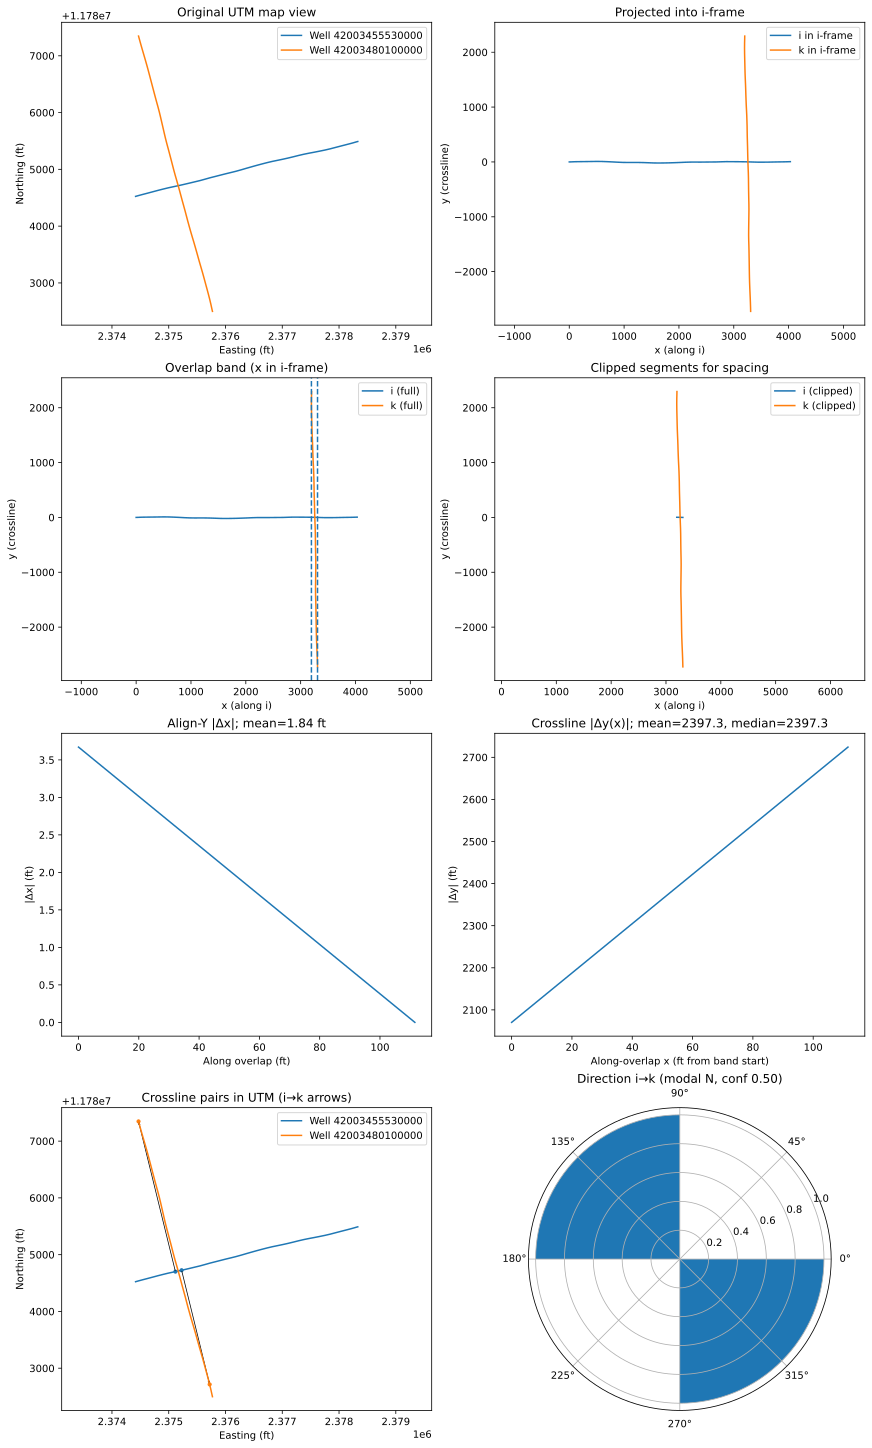

{'overlap_x_band': (3196.211103519523, 3307.746076534415),
 'alignY_mean_dx_ft': 1.8354170456927932,
 'alignY_n_samples': 2,
 'crossline_mean_ft': 2397.3099248035414,
 'crossline_median_ft': 2397.3099248035414,
 'crossline_p05_ft': 2103.0389268281106,
 'crossline_p95_ft': 2691.580922778972,
 'crossline_n_stations': 2,
 'direction_mode_4way': 'N',
 'direction_confidence': 0.5,
 'direction_distribution': {'N': 0.5, 'S': 0.5},
 'paths': {}}

In [16]:
debug_pair_spacing(
    df=df_utm_lateral,
    uwi_i='42003455530000',
    uwi_k='42003480100000',
    step_ft=100,
    use_pca_axis=True
)